In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn torch transformers nltk kaggle

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
import string

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
df = pd.read_csv("email.csv")

df.head()

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5573 entries, 0 to 5572
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5573 non-null   object
 1   Message   5573 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [ ]:
df = df.rename(columns={
    'Category': 'label',
    'Message': 'text'
})

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747
"{""mode"":""full""",1


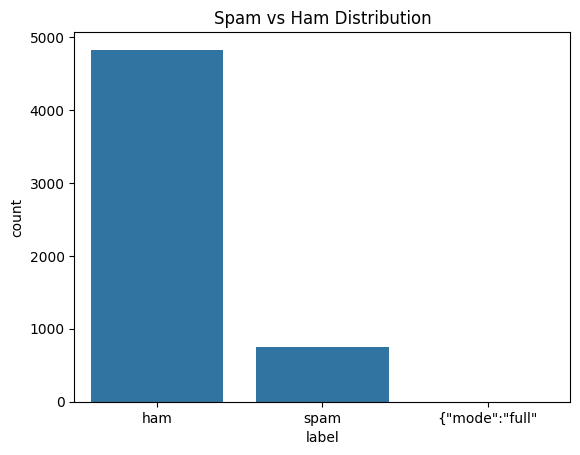

In [ ]:
sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Distribution")

plt.show()

In [ ]:
df.isnull().sum()

,0
label,0
text,0


In [ ]:
import re
import string

def clean_text(text):

    text = text.lower()

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = text.strip()

    return text


df['text'] = df['text'].apply(clean_text)

df.head()

,label,text
0,ham,go until jurong point crazy available only in ...
1,ham,ok lar joking wif u oni
2,spam,free entry in a wkly comp to win fa cup final...
3,ham,u dun say so early hor u c already then say
4,ham,nah i dont think he goes to usf he lives aroun...


In [ ]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

In [ ]:
df['label'].isnull().sum()

np.int64(1)

In [ ]:
df = df.dropna(subset=['label'])

In [ ]:
df['label'].isnull().sum()

np.int64(0)

In [ ]:
X = df['text']
y = df['label']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

In [ ]:
X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Naive Bayes Performance")

print("Accuracy:", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall:", recall_score(y_test, nb_pred))
print("F1 Score:", f1_score(y_test, nb_pred))

Naive Bayes Performance
Accuracy: 0.9739910313901345
Precision: 1.0
Recall: 0.8053691275167785
F1 Score: 0.8921933085501859


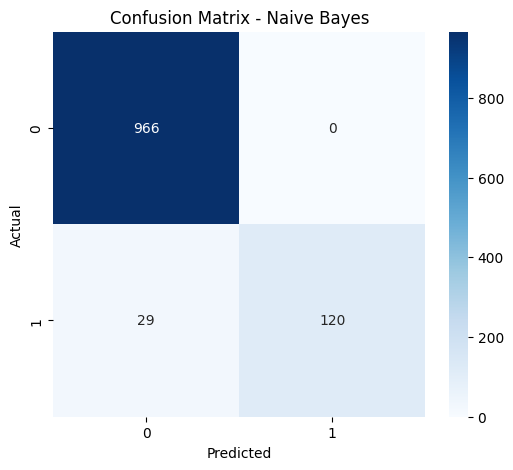

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_nb = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Naive Bayes")

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

In [ ]:
print("Logistic Regression Performance")

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))

Logistic Regression Performance
Accuracy: 0.9641255605381166
Precision: 1.0
Recall: 0.7315436241610739
F1 Score: 0.8449612403100775


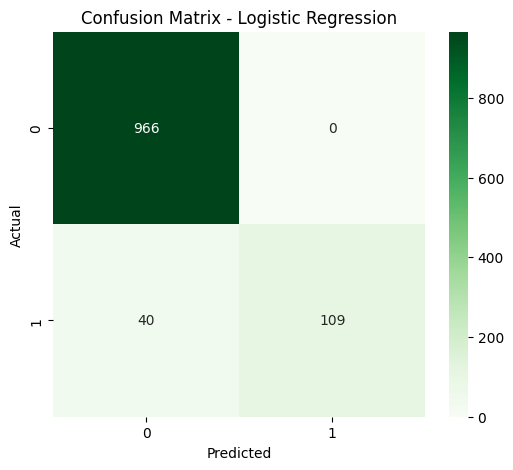

In [ ]:
cm_lr = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [ ]:
import pandas as pd

results = pd.DataFrame({

    'Model': ['Naive Bayes','Logistic Regression'],

    'Accuracy': [
        accuracy_score(y_test, nb_pred),
        accuracy_score(y_test, lr_pred)
    ],

    'Precision': [
        precision_score(y_test, nb_pred),
        precision_score(y_test, lr_pred)
    ],

    'Recall': [
        recall_score(y_test, nb_pred),
        recall_score(y_test, lr_pred)
    ],

    'F1 Score': [
        f1_score(y_test, nb_pred),
        f1_score(y_test, lr_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.973991,1.0,0.805369,0.892193
1,Logistic Regression,0.964126,1.0,0.731544,0.844961


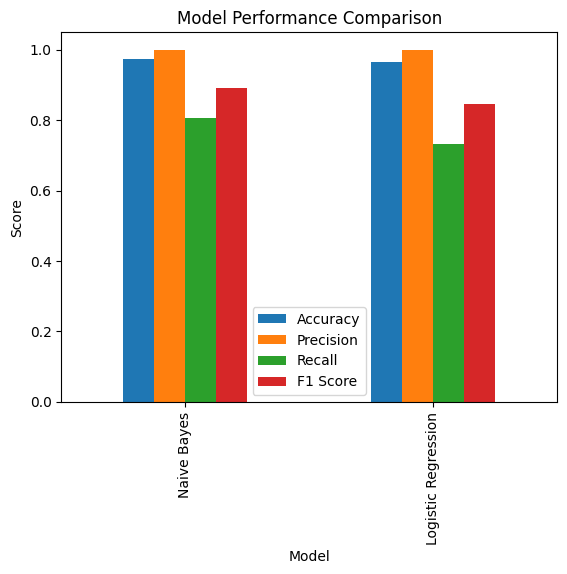

In [ ]:
results.set_index('Model').plot(kind='bar')

plt.title("Model Performance Comparison")

plt.ylabel("Score")

plt.show()

In [ ]:
!pip install transformers

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.optim import AdamW

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
texts = df['text'].tolist()
labels = df['label'].tolist()

In [ ]:
from sklearn.model_selection import train_test_split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42
)

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

In [ ]:
class EmailDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item

    def __len__(self):
        return len(self.labels)

In [ ]:
train_dataset = EmailDataset(train_encodings, train_labels)
test_dataset = EmailDataset(test_encodings, test_labels)

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

cuda


In [ ]:
optimizer = AdamW(model.parameters(), lr=5e-5)

In [ ]:
epochs = 3
train_losses = []

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(
            input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss
        total_loss += loss.item()

        loss.backward()
        optimizer.step()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print("Epoch", epoch+1, "Loss:", avg_loss)

Epoch 1 Loss: 0.028632652206015925
Epoch 2 Loss: 0.013169521306504539
Epoch 3 Loss: 0.009904087062672241


In [ ]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)

        logits = outputs.logits
        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())
        true_labels.extend(labels.cpu().numpy())

In [ ]:
accuracy = accuracy_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9901345291479821
Precision: 0.9726027397260274
Recall: 0.9530201342281879
F1 Score: 0.9627118644067797


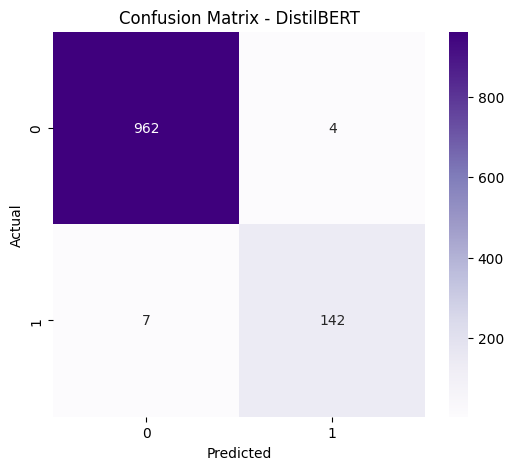

In [ ]:
cm = confusion_matrix(true_labels, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - DistilBERT")

plt.show()

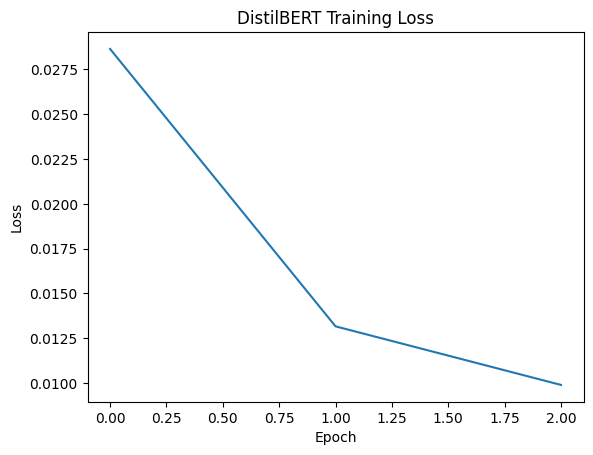

In [ ]:
plt.plot(train_losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DistilBERT Training Loss")

plt.show()

# Spam Classification Mini Project
## Comparative Study of Traditional Machine Learning and Transformer Models

Setup Environment

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn torch transformers nltk kaggle

Import Libraries

In [ ]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re
import string

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

Load Dataset

In [ ]:
df = pd.read_csv("email.csv")
df.head()

Dataset Information

In [ ]:
df.info()
df.isnull().sum()

Rename Columns

In [ ]:
df = df.rename(columns={
    'Category':'label',
    'Message':'text'
})

Visualize Class Distribution

In [ ]:
sns.countplot(x='label', data=df)

plt.title("Spam vs Ham Distribution")

plt.show()

Text Preprocessing

In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = text.strip()

    return text

df['text'] = df['text'].apply(clean_text)

df.head()

Convert Labels

In [ ]:
df['label'] = df['label'].map({
    'ham':0,
    'spam':1
})

Train Test Split

In [ ]:
X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Part A — Traditional Machine Learning

TF-IDF Vectorization

In [ ]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

Train Naive Bayes

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_pred = nb_model.predict(X_test_tfidf)

Evaluate Naive Bayes

In [ ]:
print("Naive Bayes Results")

print("Accuracy:", accuracy_score(y_test, nb_pred))
print("Precision:", precision_score(y_test, nb_pred))
print("Recall:", recall_score(y_test, nb_pred))
print("F1 Score:", f1_score(y_test, nb_pred))

Confusion Matrix (Naive Bayes)

In [ ]:
cm_nb = confusion_matrix(y_test, nb_pred)

sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues')

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Train Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()

lr_model.fit(X_train_tfidf, y_train)

lr_pred = lr_model.predict(X_test_tfidf)

Evaluate Logistic Regression

In [ ]:
print("Logistic Regression Results")

print("Accuracy:", accuracy_score(y_test, lr_pred))
print("Precision:", precision_score(y_test, lr_pred))
print("Recall:", recall_score(y_test, lr_pred))
print("F1 Score:", f1_score(y_test, lr_pred))

Confusion Matrix (Logistic Regression)

In [ ]:
cm_lr = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens')

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# Part B — Transformer Model (DistilBERT)

Install Transformers

In [ ]:
!pip install transformers

Import Transformer Libraries

In [ ]:
import torch

from transformers import DistilBertTokenizer
from transformers import DistilBertForSequenceClassification

from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

Prepare Text and Labels

In [ ]:
texts = df['text'].tolist()
labels = df['label'].tolist()

train_texts, test_texts, train_labels, test_labels = train_test_split(
    texts,
    labels,
    test_size=0.2,
    random_state=42
)

Tokenization

In [ ]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

Dataset Class

In [ ]:
class EmailDataset(Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):

        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}

        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)

        return item

    def __len__(self):
        return len(self.labels)

Create Dataset

In [ ]:
train_dataset = EmailDataset(train_encodings, train_labels)

test_dataset = EmailDataset(test_encodings, test_labels)

Load DistilBERT Model

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=2
)

DataLoader

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

test_loader = DataLoader(test_dataset, batch_size=16)

GPU Setup

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

Optimizer

In [ ]:
optimizer = AdamW(model.parameters(), lr=5e-5)

Training Loop

In [ ]:
epochs = 3

train_losses = []

for epoch in range(epochs):

    model.train()

    total_loss = 0

    for batch in train_loader:

        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)

        attention_mask = batch['attention_mask'].to(device)

        labels = batch['labels'].to(device)

        outputs = model(
            input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        loss = outputs.loss

        total_loss += loss.item()

        loss.backward()

        optimizer.step()

    avg_loss = total_loss / len(train_loader)

    train_losses.append(avg_loss)

    print("Epoch", epoch+1, "Loss:", avg_loss)

Evaluation

In [ ]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch['input_ids'].to(device)

        attention_mask = batch['attention_mask'].to(device)

        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)

        logits = outputs.logits

        preds = torch.argmax(logits, dim=1)

        predictions.extend(preds.cpu().numpy())

        true_labels.extend(labels.cpu().numpy())

Metrics

In [ ]:
accuracy = accuracy_score(true_labels, predictions)

precision = precision_score(true_labels, predictions)

recall = recall_score(true_labels, predictions)

f1 = f1_score(true_labels, predictions)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Confusion Matrix

In [ ]:
cm = confusion_matrix(true_labels, predictions)

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')

plt.title("DistilBERT Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Training Loss Graph

In [ ]:
plt.plot(train_losses)

plt.title("DistilBERT Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()